# Age and Gender Prediction with Custom CNN

This notebook builds a lightweight **Custom CNN** to simultaneously predict:
- **Age** — framed as a regression task
- **Gender** — framed as a binary classification task

The model is trained on the **UTKFace** dataset using grayscale face images.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
import random

import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
folder_path = 'utkcropped'

## Dataset Loading

The UTKFace dataset encodes age and gender directly in image filenames.
Each filename follows the pattern `age_gender_race_date.jpg`.

This section reads the filenames, parses the labels, and assembles a DataFrame for downstream use.


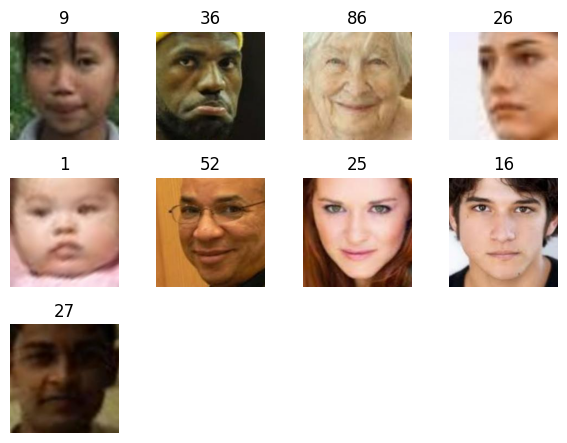

In [6]:
from PIL import Image
# Get image filenames
images = os.listdir(folder_path)

# Show first 9 images
plt.figure(figsize=(6,6))

for i, img_name in enumerate(images[:9]):
    img_path = os.path.join(folder_path, img_name)

    img = Image.open(img_path)

    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(img_name.split('_')[0])  # age from filename
    plt.axis('off')

plt.tight_layout()

plt.show()

In [7]:
import os

files = os.listdir(folder_path)

for f in files[:20]:
    print(repr(f))

'9_1_2_20161219204347420.jpg.chip.jpg'
'36_0_1_20170117163203851.jpg.chip.jpg'
'86_1_0_20170120225751953.jpg.chip.jpg'
'26_1_0_20170116171048641.jpg.chip.jpg'
'1_1_2_20161219154612988.jpg.chip.jpg'
'52_0_1_20170117161018159.jpg.chip.jpg'
'25_1_0_20170117134403373.jpg.chip.jpg'
'16_0_0_20170104003740977.jpg.chip.jpg'
'27_0_3_20170119210058457.jpg.chip.jpg'
'36_0_3_20170119180245724.jpg.chip.jpg'
'58_0_2_20170116193704928.jpg.chip.jpg'
'6_1_0_20170114024512634.jpg.chip.jpg'
'35_1_2_20170116185947151.jpg.chip.jpg'
'1_1_3_20161219230734016.jpg.chip.jpg'
'26_1_1_20170103181931657.jpg.chip.jpg'
'2_0_2_20161219141650121.jpg.chip.jpg'
'53_1_0_20170110143534851.jpg.chip.jpg'
'35_0_3_20170119201304861.jpg.chip.jpg'
'23_1_0_20170117142807780.jpg.chip.jpg'
'24_0_3_20170119152239904.jpg.chip.jpg'


In [6]:
age = []
gender = []
img_path = []
for file in os.listdir(folder_path):
    try:
        age.append(int(file.split('_')[0]))
        gender.append(int(file.split('_')[1]))
        img_path.append(file)
    except:
        print("Skipped:", file)

Skipped: .DS_Store


In [9]:
print(len(age),len(gender),len(img_path))

23709 23709 23709


In [7]:
df = pd.DataFrame({'age':age, 'gender':gender, 'img_path':img_path})

In [19]:
df.head()

,age,gender,img_path
0,9,1,9_1_2_20161219204347420.jpg.chip.jpg
1,36,0,36_0_1_20170117163203851.jpg.chip.jpg
2,86,1,86_1_0_20170120225751953.jpg.chip.jpg
3,26,1,26_1_0_20170116171048641.jpg.chip.jpg
4,1,1,1_1_2_20161219154612988.jpg.chip.jpg


In [20]:
df.shape


(23709, 3)

## Train-Test Split

The dataset is split into:
- **80%** for training
- **20%** for testing

A fixed random seed ensures reproducible splits across runs.


In [21]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

print(train_df.shape)
print(test_df.shape)


(18967, 3)
(4742, 3)


In [22]:
train_df.head()


,age,gender,img_path
20784,41,0,41_0_0_20170104202153954.jpg.chip.jpg
6425,30,1,30_1_0_20170117152122396.jpg.chip.jpg
19587,25,1,25_1_2_20170104021040316.jpg.chip.jpg
20708,1,1,1_1_2_20161219202514684.jpg.chip.jpg
13633,53,0,53_0_0_20170104184408718.jpg.chip.jpg


In [23]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [24]:
test_df.head()

,age,gender,img_path
0,45,0,45_0_1_20170117135648741.jpg.chip.jpg
1,69,1,69_1_0_20170110141308465.jpg.chip.jpg
2,26,1,26_1_2_20170116184737269.jpg.chip.jpg
3,30,1,30_1_2_20170116164737724.jpg.chip.jpg
4,15,1,15_1_0_20170109213537150.jpg.chip.jpg


## Data Augmentation

On-the-fly augmentation is applied to the training set to improve generalization.

Augmentation techniques applied:
- Random rotation (±15°)
- Width and height shifts (10%)
- Zoom (10%)
- Horizontal flip

The test set is only rescaled — no augmentation applied.


In [16]:
from tensorflow import keras

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [18]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age','gender'],
    target_size=(128,128),
    batch_size=32,
    seed = SEED,
    class_mode='multi_output'
)
test_generator = train_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age','gender'],
    target_size=(128,128),
    batch_size=32,
    seed = SEED,
    class_mode='multi_output'
)


Found 18967 validated image filenames.
Found 4742 validated image filenames.


## Custom CNN Architecture

A lightweight Custom CNN is designed to work on **grayscale images (128×128×1)**.

Key design choices:
- Four convolutional blocks with MaxPooling for hierarchical feature extraction
- Two separate dense branches — one for gender classification, one for age regression
- Dropout regularization to reduce overfitting

This architecture avoids heavy pretrained backbones, keeping the model compact and fast to train.


In [25]:
train_df.head()


,age,gender,img_path
0,41,0,41_0_0_20170104202153954.jpg.chip.jpg
1,30,1,30_1_0_20170117152122396.jpg.chip.jpg
2,25,1,25_1_2_20170104021040316.jpg.chip.jpg
3,1,1,1_1_2_20161219202514684.jpg.chip.jpg
4,53,0,53_0_0_20170104184408718.jpg.chip.jpg


In [26]:
test_df.head()

,age,gender,img_path
0,45,0,45_0_1_20170117135648741.jpg.chip.jpg
1,69,1,69_1_0_20170110141308465.jpg.chip.jpg
2,26,1,26_1_2_20170116184737269.jpg.chip.jpg
3,30,1,30_1_2_20170116164737724.jpg.chip.jpg
4,15,1,15_1_0_20170109213537150.jpg.chip.jpg


In [27]:
def load_image(img_path):
    img = tf.keras.utils.load_img(
        folder_path + "/" + img_path,
        target_size=(128, 128),
        color_mode = 'grayscale'
    )
    img = tf.keras.utils.img_to_array(img)
    img = img / 255.0   # Rescaling
    return img
    

In [28]:
X_train = np.array([load_image(path) for path in train_df['img_path']])
X_test = np.array([load_image(path) for path in test_df['img_path']])

y_train_age = train_df['age'].values
y_train_gender = train_df['gender'].values

y_test_age = test_df['age'].values
y_test_gender = test_df['gender'].values

In [24]:
from keras.layers import *
from keras.models import Model

In [29]:
input_shape = (128,128,1)

In [30]:
inputs = Input((input_shape))

conv_1 = Conv2D(32, kernel_size=(3,3), activation='relu')(inputs)
maxp_1 = MaxPooling2D(pool_size=(2,2))(conv_1)

conv_2 = Conv2D(32, kernel_size=(3,3), activation='relu')(maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2,2))(conv_2)

conv_3 = Conv2D(32, kernel_size=(3,3), activation='relu')(maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2,2))(conv_3)

conv_4 = Conv2D(32, kernel_size=(3,3), activation='relu')(maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2,2))(conv_4)

flatten = Flatten()(maxp_4)

# Fully connected layers
dense_1 = Dense(256, activation = 'relu')(flatten)
dense_2 = Dense(256, activation = 'relu')(flatten)

dropout_1 = Dropout(0.3)(dense_1)
dropout_2 = Dropout(0.3)(dense_2)

gender_out = Dense(1, activation = 'sigmoid', name = 'gender_out')(dropout_1)
age_out = Dense(1, activation = 'relu', name = 'age_out')(dropout_2)

In [31]:
model_3 = Model(inputs = inputs, outputs = [gender_out,age_out])

In [34]:
model_3.compile(
    optimizer='adam',
    loss={
        'gender_out': 'binary_crossentropy',
        'age_out': 'mae'
    },
    metrics={
        'gender_out': ['accuracy'],
        'age_out': ['mae']
    }
)

In [33]:
model_3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │      9,248 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │      9,248 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 32)  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1152)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    295,168 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    295,168 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 618,914 (2.36 MB)

 Trainable params: 618,914 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "utkface_model_3.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

## Model Training

The Custom CNN is trained with the following setup:
- **Early Stopping** — halts training when validation loss stops improving (patience = 5)
- **Model Checkpointing** — saves the best weights automatically based on validation loss

Training runs for up to 30 epochs using a batch size of 32.


In [38]:
history_3 = model_3.fit(
    X_train,
    {
        'gender_out': y_train_gender,
        'age_out': y_train_age
    },
    validation_data=(
        X_test,
        {
            'gender_out': y_test_gender,
            'age_out': y_test_age
        }
    ),
    batch_size=32,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30
592/593 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - age_out_loss: 16.8227 - age_out_mae: 16.8227 - gender_out_accuracy: 0.5295 - gender_out_loss: 0.6988 - loss: 17.5215
Epoch 1: val_loss improved from None to 13.91890, saving model to utkface_model_3.keras

Epoch 1: finished saving model to utkface_model_3.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - age_out_loss: 15.1689 - age_out_mae: 15.1717 - gender_out_accuracy: 0.5730 - gender_out_loss: 0.6656 - loss: 15.8373 - val_age_out_loss: 13.3898 - val_age_out_mae: 13.3904 - val_gender_out_accuracy: 0.7267 - val_gender_out_loss: 0.5295 - val_loss: 13.9189
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - age_out_loss: 12.1467 - age_out_mae: 12.1467 - gender_out_accuracy: 0.7404 - gender_out_loss: 0.5306 - loss: 12.6773
Epoch 2: val_loss improved from 13.91890 to 12.05137, saving model to utkface_model_3.keras

Epoch 2: finished saving model to utkface_model_3.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - age_out_loss: 11

## Training Curves

The plots below visualize model performance over training epochs:
- **Gender Classification Accuracy** — training vs. validation
- **Total Loss** — combined gender and age loss curves

These curves help diagnose overfitting or underfitting behavior.


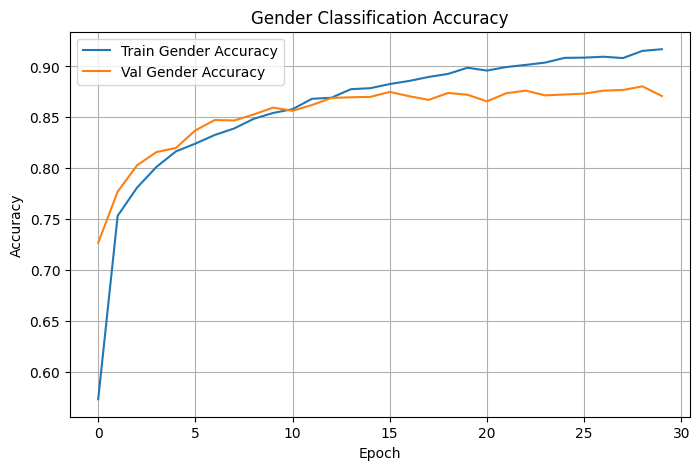

In [40]:
# Gender Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_3.history['gender_out_accuracy'], label='Train Gender Accuracy')
plt.plot(history_3.history['val_gender_out_accuracy'], label='Val Gender Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()

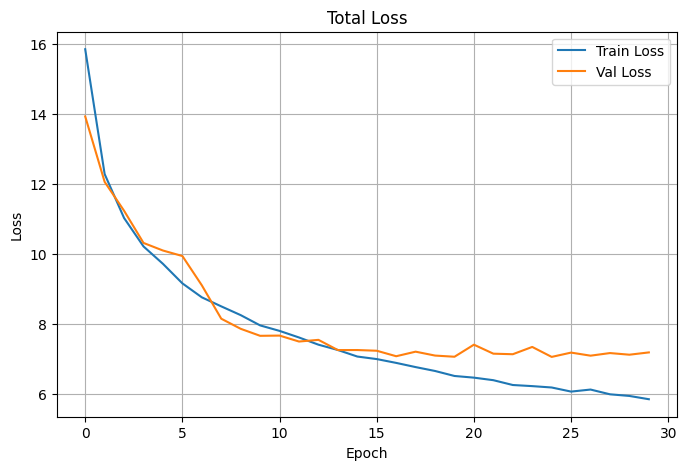

In [41]:
# Total Loss
plt.figure(figsize=(8,5))
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation

The best checkpoint is reloaded and evaluated on the held-out test set.

Metrics reported:
- **Gender Accuracy** — fraction of correctly predicted genders
- **Age MAE** — mean absolute error in predicted age (years)


In [4]:
from tensorflow.keras.models import load_model

model = load_model("utkface_model_3.keras")

In [33]:
gender_pred, age_pred = model.predict(X_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


In [34]:
from sklearn.metrics import accuracy_score

gender_pred = (gender_pred > 0.5).astype(int)

gender_acc = accuracy_score(
    y_test_gender,
    gender_pred.flatten()
)

print("Gender Accuracy:", gender_acc)

Gender Accuracy: 0.8724167018135808


In [35]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test_age,
    age_pred.flatten()
)

print("Age MAE:", mae)

Age MAE: 6.7552385330200195


# Conclusion

**Final Results (Custom CNN):**
- Age MAE: ~6.8 years
- Gender Accuracy: ~87%

**Key Observations:**
- Gender classification is significantly easier than age regression.
- Grayscale input reduces model complexity with minimal accuracy trade-off.
- Early stopping effectively prevents overfitting on this dataset.

**Potential Improvements:**
- Experimenting with deeper architectures (e.g., EfficientNet)
- Applying face alignment as a preprocessing step
- Addressing class imbalance across age groups
